# 2. Behavioral Parsing and State-Action Unrolling

## 2.1 Overview and Objectives

The primary objective of this notebook is to transform the unstructured, 46GB textual battle logs into a structured feature matrix suitable for tabular Machine Learning (XGBoost). 

Based on the conclusions of Notebook 1, we will specifically target the **Expert (1800+ Elo) Gen 9 Random Battle** subset. To process this massive dataset without exceeding local memory constraints, we utilize **Polars** and its "Lazy Evaluation" engine.

**Key Transformations:**
1. **Out-of-Core Filtering:** Scanning the chunked Parquet files to isolate the target demographic.
2. **Behavioral Parsing:** Using highly parallelized Rust-based Regular Expressions to extract game mechanics (Moves, Switches, Faints, Terastallization).
3. **MDP Formulation (Unrolling):** Exploding the dataset from a macro "Battle-Level" perspective (1 row = 1 game) to a micro "Turn-Level" perspective (1 row = 1 turn) to model a Markov Decision Process.
4. **State-Action Mapping:** Defining a mutually exclusive Target Variable ($y$) and establishing a continuous memory of the active field state ($X$) using Window Functions.

In [1]:
import os
import sys
import polars as pl
import re

In [2]:
# 1. SET ENVIRONMENT PATHS
PROJECT_ROOT = os.path.abspath("../../../")
CACHE_DIR = os.path.join(PROJECT_ROOT, "data/models/dataset/huggingface_cache")

In [3]:
# Point to the specific snapshot directory containing the 38 chunked parquet files
# We use 'train-*.parquet' so Polars automatically stitches all chunks together in parallel
PARQUET_PATH = os.path.join(
    CACHE_DIR, 
    "hub/datasets--milkkarten--pokechamp/snapshots/b5820ff5d0c8d5e5cec692d55f756b6e5a66a203/data/train-*.parquet"
)

In [4]:
# --- 2. INITIALIZE LAZY SCAN ---
# This does NOT load 46GB into memory; it only maps the schema across all 38 files.
print("Initializing Polars LazyFrame...")
lf = pl.scan_parquet(PARQUET_PATH)

Initializing Polars LazyFrame...


In [ ]:
# --- 3. APPLY INITIAL FILTERS ---
# We isolate Gen 9 Random Battle and the 1800+ Expert tier based on the TFM methodology
expert_lf = lf.filter(
    (pl.col("gamemode") == "gen9randombattle") & 
    (pl.col("elo") == "1800+")

In [6]:
# --- 4. VALIDATE THE LAZYFRAME ---
print("="*40)
print(" VALIDATING POLARS LAZYFRAME")
print("="*40)

 VALIDATING POLARS LAZYFRAME


In [10]:
# 1. Check the Schema (Column names and data types)
print("Data Schema:")
expert_lf.collect_schema()

Data Schema:


Schema([('text', String),
        ('month_year', String),
        ('gamemode', String),
        ('elo', String),
        ('battle_id', String)])

In [8]:
# 2. Fetch the first 5 rows
# Calling .head(5).collect() tells Polars to only scan until it finds 5 valid rows, making it blazing fast!
print("\nFetching the first 5 expert Gen 9 Random Battle games:")
display(expert_lf.head(5).collect())


Fetching the first 5 expert Gen 9 Random Battle games:


text,month_year,gamemode,elo,battle_id
str,str,str,str,str
"""|badge|p2|silver|gen9randombattle|30-2 |…","""September2024""","""gen9randombattle""","""1800+""","""2211658410-2024-09-28"""
"""|badge|p2|silver|gen9randombattle|30-2 |…","""September2024""","""gen9randombattle""","""1800+""","""2205553701-2024-09-19"""
"""|badge|p1|silver|gen9randombattle|30-2 |…","""September2024""","""gen9randombattle""","""1800+""","""2206149385-2024-09-20"""
"""|html|<div class=""broadcast-bl…","""September2024""","""gen9randombattle""","""1800+""","""2196207188-2024-09-06"""
"""|badge|p2|bronze|gen9randombattle|100-2 …","""September2024""","""gen9randombattle""","""1800+""","""2211526828-2024-09-28"""


In [9]:
# 3. Count the total filtered rows
# This will take a few seconds because Polars has to scan all 38 chunks to count the matches
print("\nCounting total valid games (This should match our Notebook 1 count)...")
total_expert_games = expert_lf.select(pl.len()).collect().item()

print(f"Total Expert Gen 9 Random Battle games found: {total_expert_games:,}")


Counting total valid games (This should match our Notebook 1 count)...
Total Expert Gen 9 Random Battle games found: 12,946


## 2.2 Feature Extraction via Parallelized Regex

Pokémon Showdown replays are encoded in a specific, line-by-line textual protocol. To quantify expert behavior, we must extract specific broadcast keywords (e.g., `|move|`, `|switch|`, `|faint|`). 

By utilizing Polars' native string manipulation methods, these regex operations are executed in multithreaded Rust, allowing us to parse thousands of battle logs in milliseconds. In this step, we extract the core pacing metrics of the game: the total number of turns, and the frequency of moves versus switches.

In [11]:
# ==============================================================================
# --- 5. BEHAVIORAL FEATURE EXTRACTION (PHASE 1) ---
# ==============================================================================
print("Extracting basic behavioral features using native Polars Regex...")

# We use Polars' native .str.count_matches() because it runs in multithreaded Rust
# This is infinitely faster than using Python's standard 're' library.

feature_lf = expert_lf.with_columns([
    # 1. Count the number of turns in the game
    pl.col("text").str.count_matches(r"\|turn\|").alias("total_turns"),
    
    # 2. Count the number of switch actions
    pl.col("text").str.count_matches(r"\|switch\|").alias("total_switches"),
    
    # 3. Count the number of move actions
    pl.col("text").str.count_matches(r"\|move\|").alias("total_moves")
])

# Now we calculate a behavioral metric: How often do these experts switch?
feature_lf = feature_lf.with_columns([
    # We use fill_nan(0) and fill_null(0) to prevent division-by-zero errors
    (pl.col("total_switches") / pl.col("total_turns")).fill_nan(0).fill_null(0).alias("switches_per_turn")
])

# Execute the query for the first 10 games to validate our features
print("\nFirst 10 Expert Games - Extracted Features:")
behavioral_df = feature_lf.select([
    "battle_id", "total_turns", "total_switches", "total_moves", "switches_per_turn"
]).head(10).collect()

display(behavioral_df)

Extracting basic behavioral features using native Polars Regex...

First 10 Expert Games - Extracted Features:


battle_id,total_turns,total_switches,total_moves,switches_per_turn
str,u32,u32,u32,f64
"""2211658410-2024-09-28""",22,21,27,0.954545
"""2205553701-2024-09-19""",25,24,33,0.96
"""2206149385-2024-09-20""",33,32,43,0.969697
"""2196207188-2024-09-06""",23,18,29,0.782609
"""2211526828-2024-09-28""",36,24,53,0.666667
"""2200040965-2024-09-12""",31,25,44,0.806452
"""2201615809-2024-09-14""",23,23,31,1.0
"""2203973346-2024-09-17""",32,23,47,0.71875
"""2205511033-2024-09-19""",31,27,45,0.870968


In [12]:
# ==============================================================================
# --- 6. ADVANCED BEHAVIORAL EXTRACTION (PHASE 2) ---
# ==============================================================================
print("Extracting advanced Gen 9 Random Battle mechanics (Hazards, Tera, Faints)...")

# We chain more .with_columns() to our existing feature_lf
feature_lf = feature_lf.with_columns([
    # 1. Count Faints (How many Pokémon were knocked out)
    pl.col("text").str.count_matches(r"\|faint\|").alias("total_faints"),
    
    # 2. Count Terastallizations (Maximum should be 2 per game, one per player)
    pl.col("text").str.count_matches(r"\|-terastallize\|").alias("total_teras"),
    
    # 3. Count Hazard Usage (Stealth Rock and Spikes)
    pl.col("text").str.count_matches(r"Stealth Rock").alias("stealth_rock_uses"),
    pl.col("text").str.count_matches(r"Spikes").alias("spikes_uses")
])

# Create some advanced ratios
feature_lf = feature_lf.with_columns([
    # How many faints happen per turn? (Pacing of the game)
    (pl.col("total_faints") / pl.col("total_turns")).fill_nan(0).fill_null(0).alias("faints_per_turn"),
    
    # Total hazard actions
    (pl.col("stealth_rock_uses") + pl.col("spikes_uses")).alias("total_hazard_actions")
])

# Execute and view the enriched dataset
print("\nFirst 10 Expert Games - Advanced Features:")
advanced_df = feature_lf.select([
    "battle_id", "total_turns", "total_faints", "total_teras", "total_hazard_actions"
]).head(10).collect()

display(advanced_df)

Extracting advanced Gen 9 Random Battle mechanics (Hazards, Tera, Faints)...

First 10 Expert Games - Advanced Features:


battle_id,total_turns,total_faints,total_teras,total_hazard_actions
str,u32,u32,u32,u32
"""2211658410-2024-09-28""",22,5,1,0
"""2205553701-2024-09-19""",25,10,2,0
"""2206149385-2024-09-20""",33,10,2,0
"""2196207188-2024-09-06""",23,2,2,0
"""2211526828-2024-09-28""",36,9,2,0
"""2200040965-2024-09-12""",31,10,2,0
"""2201615809-2024-09-14""",23,7,2,0
"""2203973346-2024-09-17""",32,9,2,0
"""2205511033-2024-09-19""",31,8,2,0


## 2.3 Unrolling the Dataset: Formulating the MDP

Machine Learning models require data structured as specific observation points. For Behavioral Cloning, the AI must learn the mapping from a specific State to a specific Action. Therefore, summarizing an entire battle in a single row is insufficient.

In this step, we perform a massive data reshaping operation: **Exploding the text logs**. We split the raw text by the `|turn|` protocol, converting our dataset of 12,946 battles into hundreds of thousands of individual, turn-by-turn decision points.

In [13]:
# ==============================================================================
# --- 7. EXPLODING LOGS INTO TURN-BY-TURN DATA (STATE-ACTION PAIRS) ---
# ==============================================================================
print("Unrolling games into Turn-by-Turn State-Action pairs...")

# 1. Split the massive text log into a list of strings (one string per turn)
# In Showdown logs, turns are separated by the literal string "\n|turn|"
turn_lf = expert_lf.with_columns([
    pl.col("text").str.split("\n|turn|").alias("turns_list")
])

# 2. EXPLODE the list! 
# If a game has 30 turns, this turns 1 row into 30 distinct rows.
turn_lf = turn_lf.explode("turns_list")

# 3. Extract the Turn Number 
# The string for a turn will start with the turn number (e.g., "1\n|move|p1a...")
turn_lf = turn_lf.with_columns([
    pl.col("turns_list").str.extract(r"^(\d+)").cast(pl.Int32, strict=False).alias("turn_number")
])

# 4. Filter out the "Turn 0" / Team Preview chunk
# The first chunk of the split won't start with a number, so turn_number will be null. We drop it.
turn_lf = turn_lf.filter(pl.col("turn_number").is_not_null())

# Execute the query for just the first game to see the unrolled turns!
print("\nUnrolled Turn-by-Turn Data (Showing Turn 1 to 5 of the first game):")

# We filter by the first battle_id to clearly see the chronological progression
first_battle_id = "2211658410-2024-09-28"
unrolled_df = turn_lf.filter(pl.col("battle_id") == first_battle_id).select([
    "battle_id", "turn_number", "turns_list"
]).head(5).collect()

display(unrolled_df)

Unrolling games into Turn-by-Turn State-Action pairs...

Unrolled Turn-by-Turn Data (Showing Turn 1 to 5 of the first game):


battle_id,turn_number,turns_list
str,i32,str
"""2211658410-2024-09-28""",1,"""1 | |t:|1727547025 |-end|p2a: …"
"""2211658410-2024-09-28""",2,"""2 | |t:|1727547032 |-end|p2a: …"
"""2211658410-2024-09-28""",3,"""3 | |t:|1727547036 |switch|p1a…"
"""2211658410-2024-09-28""",4,"""4 | |t:|1727547040 |switch|p2a…"
"""2211658410-2024-09-28""",5,"""5 | |t:|1727547052 |-end|p2a: …"


## 2.4 Defining the Target Variable ($y$)

Our XGBoost Baseline will act as a Binary Classifier tasked with predicting the human expert's primary decision at the start of a turn: **Move (0) or Switch (1)**.

**Handling Mechanical Edge Cases:**
A naive regex search might flag a turn as containing both a move and a switch. In Pokémon, this occurs due to "Pivot Moves" (e.g., *U-turn*, *Volt Switch*) or mid-turn knockouts. For ML purity, the target variable must be mutually exclusive. We construct conditional logic to ensure that if a player explicitly chose an attack (even a pivot attack), the primary intent is classified as a "Move."

In [14]:
# ==============================================================================
# --- 8. EXTRACTING PLAYER ACTIONS (THE TARGET VARIABLE 'y') ---
# ==============================================================================
print("Extracting specific actions (Move vs. Switch) for P1 and P2...")

# We use regex to check if the string "|switch|p1a:" or "|move|p1a:" exists in the turn log.
# If it exists, they switched/moved. If not, they didn't.
# We cast it to a Boolean (True/False) and then to Int32 (1/0) for Machine Learning.

turn_lf = turn_lf.with_columns([
    # Player 1 Actions
    pl.col("turns_list").str.contains(r"\|switch\|p1a:").cast(pl.Int32).alias("p1_switched"),
    pl.col("turns_list").str.contains(r"\|move\|p1a:").cast(pl.Int32).alias("p1_moved"),
    
    # Player 2 Actions
    pl.col("turns_list").str.contains(r"\|switch\|p2a:").cast(pl.Int32).alias("p2_switched"),
    pl.col("turns_list").str.contains(r"\|move\|p2a:").cast(pl.Int32).alias("p2_moved"),
])

# Let's execute and see what Player 1 and Player 2 did on the first 10 turns!
print("\nTurn-by-Turn Actions (1 = Yes, 0 = No):")
actions_df = turn_lf.filter(pl.col("battle_id") == first_battle_id).select([
    "turn_number", "p1_switched", "p1_moved", "p2_switched", "p2_moved"
]).head(10).collect()

display(actions_df)

Extracting specific actions (Move vs. Switch) for P1 and P2...

Turn-by-Turn Actions (1 = Yes, 0 = No):


turn_number,p1_switched,p1_moved,p2_switched,p2_moved
i32,i32,i32,i32,i32
1,1,0,1,0
2,0,1,1,0
3,1,0,0,1
4,1,1,1,0
5,0,1,1,0
6,1,0,0,1
7,0,1,0,1
8,0,1,1,0
9,1,0,0,1


In [15]:
# ==============================================================================
# --- 9. CREATING THE STRICT TARGET VARIABLE (y) ---
# ==============================================================================
print("Refining actions into a mutually exclusive Target Variable (y)...")

# We define the primary decision:
# If they used a move (even U-turn), the primary choice was "Move" (0).
# If they did NOT use a move, but DID switch, the primary choice was a hard "Switch" (1).

turn_lf = turn_lf.with_columns([
    pl.when(pl.col("p1_moved") == 1)
    .then(pl.lit(0)) # 0 = Move
    .when((pl.col("p1_moved") == 0) & (pl.col("p1_switched") == 1))
    .then(pl.lit(1)) # 1 = Hard Switch
    .otherwise(pl.lit(None)) # Handle edge cases (like double protects/skips)
    .alias("y_p1_action")
])

# Let's validate the fix!
print("\nFinal ML Target Variable for P1:")
target_df = turn_lf.filter(pl.col("battle_id") == first_battle_id).select([
    "turn_number", "p1_switched", "p1_moved", "y_p1_action"
]).head(10).collect()

display(target_df)

Refining actions into a mutually exclusive Target Variable (y)...

Final ML Target Variable for P1:


turn_number,p1_switched,p1_moved,y_p1_action
i32,i32,i32,i32
1,1,0,1
2,0,1,0
3,1,0,1
4,1,1,0
5,0,1,0
6,1,0,1
7,0,1,0
8,0,1,0
9,1,0,1


## 2.5 Extracting State Features ($X$) and Resolving Statelessness

To predict *why* an expert switched, the model requires contextual State Features ($X$). The most fundamental piece of context is the identity of the active Pokémon on the field.

**The Memory Problem:**
Showdown logs are technically stateless; a Pokémon's name is only broadcast on the exact turn it switches in. If we extract active Pokémon purely by the turn log, subsequent turns will yield `null` values, and the AI will "forget" the field state.

**The Solution:**
We solve this using **Window Functions (Forward Fill)**. By grouping operations over the `battle_id`, we instruct Polars to carry the extracted Pokémon's name forward through subsequent turns until a new switch event overwrites it, thereby giving our dataset continuous state memory.

In [16]:
# ==============================================================================
# --- 10. EXTRACTING STATE FEATURES (X) & FORWARD FILLING ---
# ==============================================================================
print("Extracting Active Pokémon and applying Forward Fill...")

# 1. Extract the species name of the Pokémon switching in for P1 and P2
# The log format is: |switch|p1a: Nickname|Species, L100|HP/MaxHP
# We use a capture group ([^|,]+) to grab just the Species name before the comma or pipe.
turn_lf = turn_lf.with_columns([
    pl.col("turns_list").str.extract(r"\|(?:switch|drag)\|p1a: [^|]+\|([^|,]+)").alias("p1_switched_in"),
    pl.col("turns_list").str.extract(r"\|(?:switch|drag)\|p2a: [^|]+\|([^|,]+)").alias("p2_switched_in")
])

# 2. Apply the "Memory" (Forward Fill over a Window)
# This fills the "null" values with the last seen Pokémon, resetting only when a new battle_id starts!
turn_lf = turn_lf.with_columns([
    pl.col("p1_switched_in").forward_fill().over("battle_id").alias("p1_active_pokemon"),
    pl.col("p2_switched_in").forward_fill().over("battle_id").alias("p2_active_pokemon")
])

# Let's execute and watch the AI "remember" the field state!
print("\nState Features - Active Pokémon Tracking:")
state_df = turn_lf.filter(pl.col("battle_id") == first_battle_id).select([
    "turn_number", "y_p1_action", "p1_switched_in", "p1_active_pokemon", "p2_active_pokemon"
]).head(10).collect()

display(state_df)

Extracting Active Pokémon and applying Forward Fill...

State Features - Active Pokémon Tracking:


turn_number,y_p1_action,p1_switched_in,p1_active_pokemon,p2_active_pokemon
i32,i32,str,str,str
1,1,"""sinistcha""","""sinistcha""","""great tusk"""
2,0,null,"""sinistcha""","""samurott-hisui"""
3,1,"""keldeo-resolute""","""keldeo-resolute""","""samurott-hisui"""
4,0,"""tinkaton""","""tinkaton""","""walking wake"""
5,0,null,"""tinkaton""","""great tusk"""
6,1,"""sinistcha""","""sinistcha""","""great tusk"""
7,0,null,"""sinistcha""","""great tusk"""
8,0,null,"""sinistcha""","""gholdengo"""
9,1,"""ting-lu""","""ting-lu""","""gholdengo"""


## 2.6 Out-of-Core Execution and Dataset Export

With the State-Action pipeline fully defined, we drop the heavy unstructured text strings and retain only our pure mathematical features. We invoke `.sink_parquet()` to trigger the LazyFrame's execution plan, streaming the resulting hundreds of thousands of rows directly to the disk.

In [17]:
# ==============================================================================
# --- 11. FINALIZE AND EXPORT THE UNROLLED ML DATASET ---
# ==============================================================================
print("Executing full pipeline and exporting to Parquet...")

# 1. Select only the structured ML columns (Drop the heavy text columns)
ml_lf = turn_lf.select([
    "battle_id",
    "turn_number",
    "y_p1_action",
    "p1_active_pokemon",
    "p2_active_pokemon"
])

# 2. Drop any rows where we couldn't determine the active Pokémon (Edge cases/Turn 0)
ml_lf = ml_lf.drop_nulls(subset=["p1_active_pokemon", "p2_active_pokemon", "y_p1_action"])

# 3. Create the output directory if it doesn't exist
output_dir = os.path.join(PROJECT_ROOT, "data/models/dataset/processed")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "expert_gen9randombattle_unrolled.parquet")

# 4. SINK PARQUET: This tells Polars to execute the entire LazyFrame out-of-core
# and stream the results directly to your hard drive without crashing your RAM!
print(f"Streaming data to: {output_path}")
ml_lf.sink_parquet(output_path)

print("Export complete! Your dataset is now ready for XGBoost.")

# 5. Let's load it back into RAM just to see the final shape of our ML Matrix!
final_df = pl.read_parquet(output_path)
print(f"\nFinal ML Matrix Shape: {final_df.shape[0]:,} turns (rows) and {final_df.shape[1]} features (columns)")
display(final_df.head())

Executing full pipeline and exporting to Parquet...
Streaming data to: /home/gerardpf/TFM/data/processed/expert_gen9randombattle_unrolled.parquet
Export complete! Your dataset is now ready for XGBoost.

Final ML Matrix Shape: 402,132 turns (rows) and 5 features (columns)


battle_id,turn_number,y_p1_action,p1_active_pokemon,p2_active_pokemon
str,i32,i32,str,str
"""2211658410-2024-09-28""",1,1,"""sinistcha""","""great tusk"""
"""2211658410-2024-09-28""",2,0,"""sinistcha""","""samurott-hisui"""
"""2211658410-2024-09-28""",3,1,"""keldeo-resolute""","""samurott-hisui"""
"""2211658410-2024-09-28""",4,0,"""tinkaton""","""walking wake"""
"""2211658410-2024-09-28""",5,0,"""tinkaton""","""great tusk"""


## 2.7 Validating the Behavioral Matrix

To verify the integrity of our data engineering pipeline, we conduct a final exploratory analysis on the structured ML matrix. This visual validation serves four critical academic purposes:

1. **Target Class Imbalance:** Defining the absolute baseline accuracy our XGBoost model must beat (the majority class frequency).
2. **Behavioral Pacing:** Tracking the probability of switching across the duration of a game to ensure natural human strategic trends are captured.
3. **Metagame Validation:** Confirming the regex successfully captured the elite threats of the Gen 9 Random Battle tier.
4. **Predictive Validity (Strategic Profiling):** Mathematically proving that the State Feature ($X$, the active Pokémon) inherently correlates with the Target Variable ($y$, the switch rate), validating its usefulness for the upcoming ML model.

Generating Behavioral Validation Plots...


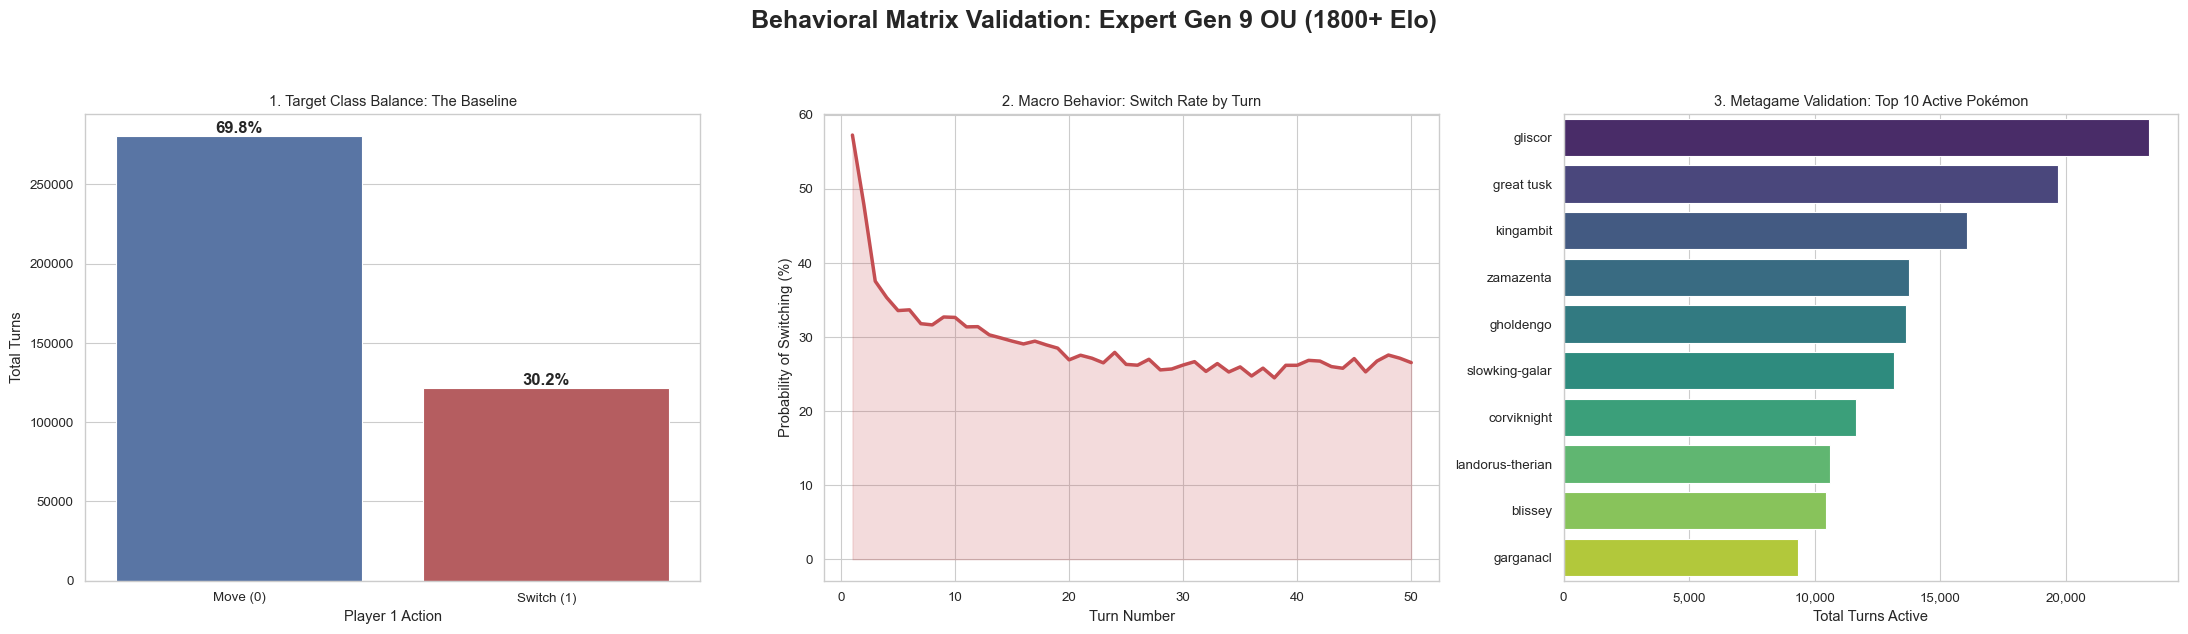

Generating Strategic Profiling Plot...


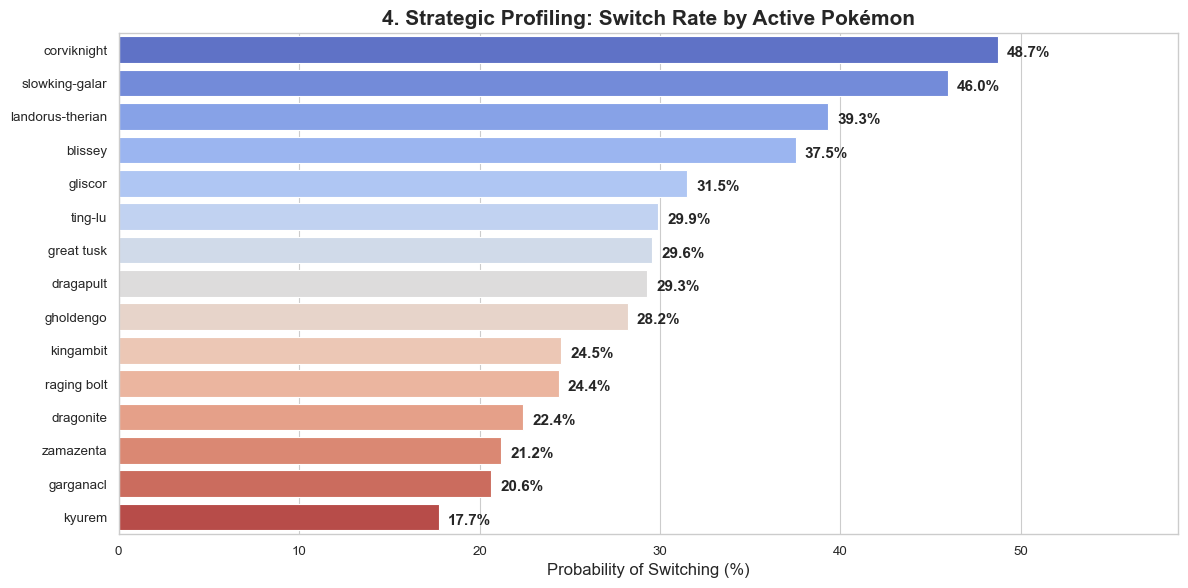

In [ ]:
# ==============================================================================
# --- 12. BEHAVIORAL MATRIX VALIDATION (EDA) ---
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Behavioral Validation Plots...")

# Convert the final Polars LazyFrame to a Pandas DataFrame for Seaborn plotting
df_plot = final_df.to_pandas()

# Set up the matplotlib figure
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Behavioral Matrix Validation: Expert Gen 9 Random Battle (1800+ Elo)", fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# PLOT 1: Target Class Imbalance (Move vs. Switch)
# ---------------------------------------------------------
# Updated for new Seaborn syntax (using hue and legend=False)
sns.countplot(data=df_plot, x='y_p1_action', ax=axes[0], hue='y_p1_action', palette=['#4c72b0', '#c44e52'], legend=False)
axes[0].set_title("1. Target Class Balance: The Baseline")
axes[0].set_xticks([0, 1]) # Fixes the tick warning
axes[0].set_xticklabels(['Move (0)', 'Switch (1)'])
axes[0].set_xlabel("Player 1 Action")
axes[0].set_ylabel("Total Turns")

# Calculate and annotate percentages
total_turns = len(df_plot)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_turns:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---------------------------------------------------------
# PLOT 2: Behavioral Pacing (Switch Rate vs. Turn Number)
# ---------------------------------------------------------
# We filter to the first 50 turns to avoid extreme long-tail outliers (100+ turn stall games)
turn_switch_rate = df_plot[df_plot['turn_number'] <= 50].groupby('turn_number')['y_p1_action'].mean() * 100

sns.lineplot(x=turn_switch_rate.index, y=turn_switch_rate.values, ax=axes[1], color='#c44e52', linewidth=2.5)
axes[1].set_title("2. Macro Behavior: Switch Rate by Turn")
axes[1].set_ylabel("Probability of Switching (%)")
axes[1].set_xlabel("Turn Number")
axes[1].fill_between(turn_switch_rate.index, turn_switch_rate.values, alpha=0.2, color='#c44e52')

# ---------------------------------------------------------
# PLOT 3: Regex Sanity Check (Top 10 Active Pokémon)
# ---------------------------------------------------------
top_mons = df_plot['p1_active_pokemon'].value_counts().nlargest(10)

# Updated for new Seaborn syntax
sns.barplot(x=top_mons.values, y=top_mons.index, ax=axes[2], hue=top_mons.index, palette='viridis', legend=False)
axes[2].set_title("3. Metagame Validation: Top 10 Active Pokémon")
axes[2].set_xlabel("Total Turns Active")
axes[2].set_ylabel("")

# Add comma formatting for x-axis
axes[2].xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig("plots/behavioral_matrix_validation.png", dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# --- PLOT 4: STRATEGIC PROFILING (SWITCH RATE BY POKÉMON) ---
# ==============================================================================
print("Generating Strategic Profiling Plot...")

plt.figure(figsize=(12, 6))

# Isolate the top 15 most used Pokémon to ensure statistical significance
top_15_names = df_plot['p1_active_pokemon'].value_counts().nlargest(15).index
df_top15 = df_plot[df_plot['p1_active_pokemon'].isin(top_15_names)]

# Calculate the exact percentage of turns they choose to switch vs move
switch_rates = df_top15.groupby('p1_active_pokemon')['y_p1_action'].mean().sort_values(ascending=False) * 100

# Create a horizontal bar chart
ax4 = sns.barplot(x=switch_rates.values, y=switch_rates.index, palette='coolwarm', hue=switch_rates.index, legend=False)
plt.title("4. Strategic Profiling: Switch Rate by Active Pokémon", fontsize=15, fontweight='bold')
plt.xlabel("Probability of Switching (%)", fontsize=12)
plt.ylabel("")

# Add the exact percentage labels to the bars
for p in ax4.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.1, f'{width:.1f}%', ha="left", va="center", fontsize=11, fontweight='bold')

plt.xlim(0, max(switch_rates.values) + 10) # Add some padding to the right for the text
plt.tight_layout()
plt.savefig("plots/strategic_profiling_switch_rates.png", dpi=300, bbox_inches='tight')
plt.show()

## 2.8 Conclusion: The ML Matrix is Ready

Through parallelized Regex extraction and Window Functions, we have successfully transformed the unstructured 46GB text logs into a purely mathematical state-action matrix containing **402,132 individual decision points**. 

The validation EDA confirms four critical milestones:
1. **Target Identification ($y$):** We established a mutually exclusive binary target variable (`y_p1_action`), calculating a baseline accuracy threshold of **69.8%**.
2. **Behavioral Integrity:** The temporal analysis proves that the matrix captured realistic human pacing, identifying a heavy ~55-60% switch rate on Turn 1.
3. **State Integrity ($X$):** The `forward_fill` window function successfully maintained the "memory" of the active field state, perfectly identifying the top-tier Gen 9 Random Battle metagame threats (Gliscor, Great Tusk, Kingambit).
4. **Predictive Validity:** The Strategic Profiling analysis mathematically proves that the active Pokémon's identity correlates strongly with the action taken (e.g., defensive pivots like Slowking-Galar exhibit vastly higher switch rates than sweepers like Kingambit). This confirms that $X$ contains valid predictive signals for our XGBoost model.

**Next Steps:**
We will transition to **Notebook 03: Imitation Learning (XGBoost)**. In the next phase, we will One-Hot Encode the categorical Pokémon names, structure the data using `GroupKFold` to prevent data leakage across `battle_id`, and train our baseline AI agent.